# QuadTrees Test

This notebook contains a minimal implementation of the library in 2-D, for the sake of demonstrating with Quadtree Generation.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm import trange

In [2]:
N = 5
BOUNDS = [10, 10]
L = 1
SIGMA = 4 * np.pi
U = SIGMA / (4 * np.pi * L ** 2) 

In [29]:
def rejoin(positions, orientations):
    return np.hstack((positions, orientations))

def split(system):
    if system.ndim == 2:
        return system[:,:2], system[:,2:]
    return system[:2], system[2:]

$$\mathbf{X} = (\mathbf{x}_c, \hat{n})$$

In [30]:
def generate_system(n):
    bounds = np.asarray(BOUNDS)
    positions = np.random.uniform(-bounds, bounds, size=(n, 2))
    # give them radial inward orientations
    orientations = -positions / np.linalg.norm(positions, axis=1, keepdims=True)
    return rejoin(positions, orientations)

In [31]:
system = generate_system(N)
print(system)

[[ 2.63150582  0.20344637 -0.99702478 -0.07708175]
 [-6.8414691   7.71302653  0.66357487 -0.74810988]
 [-7.95967155  4.12180713  0.88800195 -0.45983968]
 [ 2.23252502 -4.72821734 -0.42696811  0.90426668]
 [ 2.58341984 -4.91043315 -0.46560266  0.88499388]]


In [32]:
ORIENTATION_LENGTH=1
def plot_system(system):
    positions, orientations = split(system)
    endpoints = positions + ORIENTATION_LENGTH * orientations

    plt.figure()
    plt.scatter(*positions.T, color='red')

    for p, e in zip(positions, endpoints):
        start = [p[0], e[0]]
        end = [p[1], e[1]]
        plt.plot(start, end, color='black')

    plt.axis('equal')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()

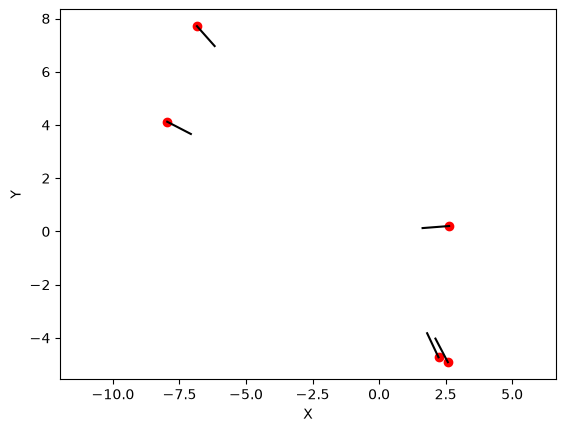

In [33]:
plot_system(system)

$$\mathbf{x}_f = \mathbf{x}_c + \vec{\delta}$$
$$\mathbf{x}_b = \mathbf{x}_c - \vec{\delta}$$
where
$$\vec{\delta} = \hat{n}\ell/2$$

In [34]:
def calc_feat_pos(mat):
    xc, nhat = split(mat)
    delta = nhat * L / 2
    return rejoin(xc + delta, xc - delta)

$$\mathbf{c}_{\alpha\beta} = \frac{\mathbf{r}_{\alpha\beta}}{r_{\alpha\beta}^2}$$
where
$$\mathbf{r}_{\alpha\beta} = \mathbf{x}_{\alpha,i} - \mathbf{x}_{\beta,j}$$

NOTE: It would be $\mathbf{r}/r^3$ in 3-D.

In [35]:
def calc_feat_inter(a, b):
    r = a - b
    return r / (np.linalg.norm(r) ** 2)

$$\mathbf{h}_{f,ij} = \mathbf{c}_{ff} - \mathbf{c}_{fb}$$
and
$$\mathbf{h}_{b,ij} = \mathbf{c}_{bf} - \mathbf{c}_{bb}$$

In [36]:
def calc_fish_interaction(fi, bi, fj, bj):
    ff = calc_feat_inter(fi, fj)
    fb = calc_feat_inter(fi, bj)
    bf = calc_feat_inter(bi, fj)
    bb = calc_feat_inter(bi, bj)
    return rejoin(ff - fb, bf - bb)

```python
Q=4 # number of quadrants
class QuadTree:
    def __init__(self, center, side_len):
        self.kids=[None]*Q
        self.center = center
        self.side_len = side_len
        self.is_leaf = True
        self.cluster_size = 0
        self.cluster = np.zeros(4)
        self.data = None

    def calc_quad_idx(self, pos):
        qidx = 0
        for i in range(2):
            if pos[i] > self.center[i]:
                qidx += 2 ** i
        return qidx

    def calc_child_center(self, cqidx):
        offset_len = self.side_len / 4
        offset = np.zeros(2)
        for di in range(2):
            db = 2 ** di
            if cqidx & db:
                offset[di] = offset_len
            else:
                offset[di] = -offset_len
        return self.center + offset

    def insert_into_kids(self, data):
        qidx = self.calc_quad_idx(data[:2])
        if self.kids[qidx] is None:
            self.kids[qidx] = QuadTree(
                center = self.calc_child_center(qidx),
                side_len = self.side_len / 2
            )
        self.kids[qidx].insert_data(data)

    def insert_data(self, data):      
        if self.is_leaf and self.data is None:
            self.data = data
        elif self.is_leaf and self.data is not None:
            old_data = self.data
            self.is_leaf = False
            self.insert_into_kids(data)
            self.insert_into_kids(old_data)
        elif not self.is_leaf:
            self.insert_into_kids(data)

        self.cluster += data
        self.cluster_size += 1
        self.avg = self.cluster / self.cluster_size
    
    def calc_feat_pos(self):
        if self.avg is not None:
            fpos = calc_feat_pos(self.avg)
            self.xf, self.xb = fpos[:2], fpos[2:]

        for qidx in range(Q):
            if self.kids[qidx] is not None:
                self.kids[qidx].calc_feat_pos()

    def compute_interaction(self, xc, xf, xb, theta):
        if self.avg is None:
            return np.zeros(4)

        if self.is_leaf:
            if np.allclose(self.avg[:2], xc):
                return np.zeros(4)
            return calc_fish_interaction(xf, xb, self.xf, self.xb)

        dist = np.linalg.norm(xc - self.center)
        if np.isclose(dist, 0):
            phi = np.inf
        else:
            phi = self.side_len / dist

        if phi < theta:
            return calc_fish_interaction(xf, xb, self.xf, self.xb)
        else:
            total_int = np.zeros(4)
            for kid in self.kids:
                if kid is not None:
                    total_int += kid.compute_interaction(xc, xf, xb, theta)
            return total_int
```

```python
def build_quadtree(system):
    pos, _ = split(system)
    mins = np.min(pos, axis=0)
    maxs = np.max(pos, axis=0)
    longest_distance = np.max(maxs - mins)

    # avoid boundary issues
    quadtree = QuadTree(
        center = (mins + maxs) / 2,
        side_len = longest_distance * 1.001
    )

    # add the fish to the tree
    for fish in system:
        quadtree.insert_data(fish)

    # compute the front and back positions
    quadtree.calc_feat_pos()

    return quadtree
```

In [60]:
import numpy as np

Q = 4
MAX_BITS = 16  # bits per axis -> 65536-cell grid, i.e. max tree depth of 16


def _spread_bits(x):
    """Insert a 0 bit between each bit of x (16-bit -> 32-bit) for Morton interleaving."""
    x = x.astype(np.uint64) & 0xFFFF
    x = (x | (x << 8)) & 0x00FF00FF
    x = (x | (x << 4)) & 0x0F0F0F0F
    x = (x | (x << 2)) & 0x33333333
    x = (x | (x << 1)) & 0x55555555
    return x


def morton_encode(ix, iy):
    """Interleave integer x/y grid coords into one Morton code (x->even bits, y->odd bits),
    matching the qidx = (x>c.x) + 2*(y>c.y) convention used elsewhere in the tree."""
    return _spread_bits(ix) | (_spread_bits(iy) << 1)


class LinearQuadTree:
    """Flat quadtree over a Morton-sorted point array."""

    def __init__(self):
        self.centers = []
        self.side_lens = []
        self.children = []
        self.is_leaf = []
        self.cluster = []
        self.cluster_size = []
        self.avg = []
        self.xf = []
        self.xb = []
        self.leaf_range = []      # (lo, hi) into sorted_data covered by this node
        self.sorted_data = None
        self.sorted_codes = None

    def _new_node(self, center, side_len, is_leaf, lo, hi):
        idx = len(self.centers)
        self.centers.append(center)
        self.side_lens.append(side_len)
        self.children.append([-1, -1, -1, -1])
        self.is_leaf.append(is_leaf)
        self.cluster.append(np.zeros(4))
        self.cluster_size.append(0)
        self.avg.append(np.zeros(4))
        self.xf.append(np.zeros(2))
        self.xb.append(np.zeros(2))
        self.leaf_range.append((lo, hi))
        return idx

    def finalize(self):
        self.centers = np.array(self.centers)
        self.side_lens = np.array(self.side_lens)
        self.children = np.array(self.children, dtype=np.int64)
        self.is_leaf = np.array(self.is_leaf, dtype=bool)
        self.cluster = np.array(self.cluster)
        self.cluster_size = np.array(self.cluster_size, dtype=np.int64)
        self.avg = np.array(self.avg)
        self.xf = np.array(self.xf)
        self.xb = np.array(self.xb)


def calc_child_center(center, side_len, qidx):
    offset_len = side_len / 4
    offset = np.array([
        offset_len if (qidx & 1) else -offset_len,
        offset_len if (qidx & 2) else -offset_len,
    ])
    return center + offset


def build_linear_quadtree(system, bits=MAX_BITS):
    pos = system[:, :2]
    n = len(system)

    mins = pos.min(axis=0)
    maxs = pos.max(axis=0)
    side_len = (maxs - mins).max() * 1.001
    center = (mins + maxs) / 2
    root_origin = center - side_len / 2  # bottom-left corner of root square

    # quantize onto an integer grid, then Morton-encode + sort once
    scale = (2 ** bits) / side_len
    grid = np.floor((pos - root_origin) * scale).astype(np.int64)
    grid = np.clip(grid, 0, 2 ** bits - 1)
    codes = morton_encode(grid[:, 0], grid[:, 1])

    order = np.argsort(codes, kind="stable")
    sorted_data = system[order]
    sorted_codes = codes[order]

    tree = LinearQuadTree()
    tree.sorted_data = sorted_data
    tree.sorted_codes = sorted_codes

    def build(lo, hi, node_center, node_side_len, depth):
        pts = sorted_data[lo:hi]
        clus = pts.sum(axis=0)
        clus_size = hi - lo
        avg = clus / clus_size

        # stop if singleton, or grid precision exhausted (handles coincident points,
        # which would recurse forever in the original pointer-based tree)
        is_leaf = (clus_size == 1) or (depth >= bits)
        idx = tree._new_node(node_center, node_side_len, is_leaf, lo, hi)
        tree.cluster[idx] = clus
        tree.cluster_size[idx] = clus_size
        tree.avg[idx] = avg

        if is_leaf:
            return idx

        shift = 2 * (bits - 1 - depth)
        qvals = (sorted_codes[lo:hi] >> shift) & 3   # already sorted -> monotonic non-decreasing
        bounds = np.searchsorted(qvals, [0, 1, 2, 3, 4]) + lo

        for q in range(Q):
            sub_lo, sub_hi = bounds[q], bounds[q + 1]
            if sub_hi > sub_lo:
                child_center = calc_child_center(node_center, node_side_len, q)
                child_idx = build(sub_lo, sub_hi, child_center, node_side_len / 2, depth + 1)
                tree.children[idx][q] = child_idx

        return idx

    root = build(0, n, center, side_len, 0)
    tree.finalize()

    fpos = calc_feat_pos(tree.avg)  # vectorized over all nodes
    tree.xf, tree.xb = fpos[:, :2], fpos[:, 2:]

    return tree, root

def compute_interaction(tree, node_idx, xc, xf, xb, theta):
    total_int = np.zeros(4)
    stack = [node_idx]

    while stack:
        i = stack.pop()
        if tree.cluster_size[i] == 0:
            continue

        if tree.is_leaf[i]:
            if np.allclose(tree.avg[i, :2], xc):
                continue
            total_int += calc_fish_interaction(xf, xb, tree.xf[i], tree.xb[i])
            continue

        dist = np.linalg.norm(xc - tree.centers[i])
        phi = np.inf if np.isclose(dist, 0) else tree.side_lens[i] / dist

        if phi < theta:
            total_int += calc_fish_interaction(xf, xb, tree.xf[i], tree.xb[i])
        else:
            for c in tree.children[i]:
                if c != -1:
                    stack.append(c)

    return total_int

In [61]:
def compute_interaction_barnes_hut(system, theta):
    n = system.shape[0]
    tree, root = build_linear_quadtree(system)
    feat_pos = calc_feat_pos(system)
    interactions = np.zeros((n, 4))
    for i in range(n):
        xci, nhati = split(system[i])
        xfi, xbi = split(feat_pos[i])
        interactions[i] = compute_interaction(tree, root, xci, xfi, xbi, theta)
    return interactions

In [62]:
def compute_interaction_pairwise(system):
    feat_pos = calc_feat_pos(system)
    n = system.shape[0]

    fpos_split = lambda idx: (feat_pos[idx, :2], feat_pos[idx, 2:])

    interactions = np.zeros((n,4))
    for i in range(n):
        fi, bi = fpos_split(i)
        interaction_total = np.zeros(4)
        
        for j in range(n):
            if i == j:
                continue
            fj, bj = fpos_split(j)
            interaction_total += calc_fish_interaction(fi, bi, fj, bj)
            
        interactions[i] = interaction_total

    return interactions

$$\mathbf{v}_{\alpha} = U \hat{n} + \frac{\sigma}{4\pi} \mathbf{h}_\alpha$$

In [63]:
def calc_feat_vel(system, theta):
    xc, nhat = split(system)
    internal = rejoin(U * nhat, U * nhat)
    interaction=None
    if np.isclose(theta, 0):
        interaction=compute_interaction_pairwise(system)
    else:
        interaction=compute_interaction_barnes_hut(system, theta)
    external = SIGMA / (4 * np.pi) * interaction
    return internal + external

$$\dot{\mathbf{X}} = (\dot{\mathbf{x}}_c, \dot{\mathbf{n}})$$
where
$$\dot{\mathbf{x}}_c = (\dot{\mathbf{x}}_f + \dot{\mathbf{x}}_b)/2$$
and
$$\dot{\mathbf{n}} = (\Delta \mathbf{v} + 2 \lambda \hat{n}) / \ell$$
where
$$\lambda = -\Delta \mathbf{v} \cdot \hat{n}$$
and
$$\Delta v = \dot{\mathbf{x}}_f - \dot{\mathbf{x}}_b$$

In [64]:
def compute_derivative(system, theta=0):
    xc, nhat = split(system)
    
    front_vel, back_vel = split(calc_feat_vel(system, theta))
    xcdot = (front_vel + back_vel) / 2

    dvel = front_vel - back_vel
    lagrange = -np.sum(dvel * nhat, axis=1)[:, np.newaxis] / 2
    ndot = (dvel + 2 * lagrange * nhat) / L

    return rejoin(xcdot, ndot)

In [65]:
print(compute_derivative(system, theta=0.1))

[[-9.42685296e-01 -1.66387452e-02 -1.50634910e-03  1.94840852e-02]
 [ 5.92735420e-01 -7.26535554e-01  9.49562341e-03  8.42263590e-03]
 [ 8.12065167e-01 -4.66490416e-01 -1.06638603e-02 -2.05931095e-02]
 [-8.78052375e-02  3.25818635e-02 -2.23918054e+00 -1.05727513e+00]
 [-8.75567664e-02 -2.53039870e-01  2.02495886e+00  1.06534774e+00]]


$$
        \begin{align}
        \dot{\mathbf{X}}_1 &= f(\mathbf{X}_0)  \\
        \dot{\mathbf{X}}_2 &= f(\mathbf{X}_0 + \dot{\mathbf{X}}_1
          \delta t_{1/2}) \\
        \dot{\mathbf{X}}_3 &= f(\mathbf{X}_0 + \dot{\mathbf{X}}_2
          \delta t_{1/2}) \\
        \dot{\mathbf{X}}_4 &= f(\mathbf{X}_0 + \dot{\mathbf{X}}_3 \delta t)
        \end{align}
$$

and

$$
\dot{\mathbf{X}} \approx \frac{\dot{\mathbf{X}}_1 + 2
        \dot{\mathbf{X}}_2 + 2 \dot{\mathbf{X}}_3 + \dot{\mathbf{X}}_4}{6}
$$

for

$$\mathbf{X}_{\delta t} = \mathbf{X}_0 + \dot{\mathbf{X}} \delta t$$

In [66]:
def update_state_rk4(system, dt, theta=0):
    f = lambda X: compute_derivative(X, theta)

    X0 = system
    
    k1 = f(X0)
    k2 = f(X0 + k1 * dt / 2)
    k3 = f(X0 + k2 * dt / 2)
    k4 = f(X0 + k3 * dt)

    k = (k1 + 2 * k2 + 2 * k3 + k4) / 6
    Xt = X0 + k * dt

    x, n = split(Xt)
    
    return rejoin(x, n / np.linalg.norm(n, axis=1, keepdims=True))

In [67]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_system(system0, dt, tf, theta=0):
    fig, ax = plt.subplots()

    n_frames = int(tf / dt)
    
    positions, orientations = split(system0)
    endpoints = positions + ORIENTATION_LENGTH * orientations

    scatter = ax.scatter(*positions.T, color='red')

    lines = []
    for p, e in zip(positions, endpoints):
        start, end = [p[0], e[0]], [p[1], e[1]]
        line, = ax.plot(start, end, color='black')
        lines.append(line)

    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    system = system0.copy()

    def update(frame):
        nonlocal system

        system = update_state_rk4(system, dt, theta=theta)
        positions, orientations = split(system)
        endpoints = positions + ORIENTATION_LENGTH * orientations

        scatter.set_offsets(positions)

        ax.set_title(f"t={frame * dt:.2f}")
        for line, p, e in zip(lines, positions, endpoints):
            start=[p[0], e[0]]
            end=[p[1], e[1]]
            line.set_data(start, end)

        return [scatter, *lines]

    ani = FuncAnimation(fig, update, frames=n_frames, interval=20, blit=True)
    return HTML(ani.to_jshtml())

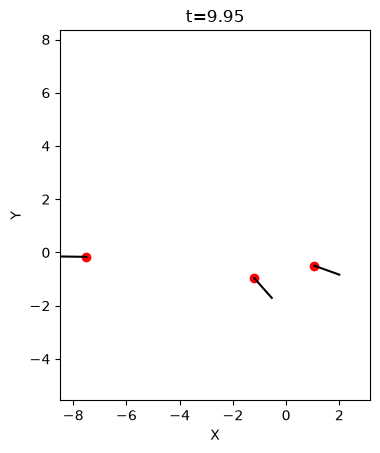

In [68]:
animate_system(system, dt=0.05, tf=10, theta=0.9)

## Timing

In [57]:
import time
def perform_time_test(n, theta, repeats=3):
    sys = generate_system(n)
    times = np.zeros(repeats)

    for i in range(repeats):
        start = time.perf_counter()
        compute_derivative(sys, theta)
        end = time.perf_counter()
        times[i] = end - start

    return np.mean(times)

In [58]:
from tqdm.notebook import tqdm
def generate_comparison_fig(min_log_n, max_log_n):
    lognvalues = np.flip(np.arange(min_log_n, max_log_n + 1))
    nvalues = np.exp2(lognvalues)

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 12))

    log_plot_ax = axes[0]
    k_asympt_ax = axes[1]

    
    # brute force
    brute_force_times = []
    for logn in tqdm(lognvalues, desc="Brute Force"):
        n = 2 ** logn
        t = perform_time_test(n, theta=0)
        brute_force_times.append(np.log2(t))

    slope_bf, intercept_bf = np.polyfit(lognvalues, brute_force_times, 1)
    prop_const_bf = 2 ** intercept_bf

    def fe(x):
        mantissa, exponent = f"{x:.6e}".split("e")
        return f"{float(mantissa):.2f} \\times 10^{{{int(exponent)}}}"

    log_plot_ax.plot(
        lognvalues, brute_force_times,
        label=f"Brute Force, $k={fe(prop_const_bf)}$, Slope$={slope_bf:.1f}$",
        linewidth=3
    )

    k_asympt_ax.plot(
        nvalues,
        np.exp2(brute_force_times) / (nvalues ** 2),
        label=r'Brute Force, $T(N)/N^2$'
    )

    # barnes-hut
    thetas = np.arange(0.25, 1.0, step=0.25)
    for theta in tqdm(thetas, leave=False, desc='Barnes-Hut'):

        # compute the times
        bh_times = []
        for logn in tqdm(lognvalues, desc=f'Barnes-Hut, Theta={theta:.2f}'):
            time = perform_time_test(2 ** logn, theta)
            bh_times.append(np.log2(time))

        slope_bh, intercept_bh = np.polyfit(lognvalues, bh_times, 1)
        prop_const_bh = 2 ** intercept_bh

        # plot
        log_plot_ax.plot(
            lognvalues, bh_times,
            label=f'Barnes-Hut, $\\theta={theta:.2f}$, '+\
            f'$k={fe(prop_const_bh)}$, Slope$={slope_bh:.1f}$',
            linewidth=3
        )

        k_asympt_ax.plot(
            nvalues,
            np.exp2(bh_times) / (nvalues * np.log2(nvalues)),
            label=f'Barnes-Hut, $\\theta={theta:.2f}$, $T(N)/(N \\log_2 N)$'
        )

    # set labels and title
    log_plot_ax.set_xlabel(r"Logarithmic Number of Fish, $\log_2 N$")
    log_plot_ax.set_ylabel(r"Logarithmic Runtime ($\log_2$ seconds)")
    log_plot_ax.set_title("Barnes–Hut vs Brute Force\nDerivative Computation Runtime")
    log_plot_ax.legend()
    log_plot_ax.grid(True)

    k_asympt_ax.set_xlabel(r'Number of Fish, $N$')
    k_asympt_ax.set_ylabel('Proportionality Cofficient $k$\n(seconds per fish)')
    k_asympt_ax.set_title('Normalized Algorithmic Runtime Growth vs. $N$')
    k_asympt_ax.legend()
    k_asympt_ax.grid(True)

    plt.plot()

Brute Force:   0%|          | 0/10 [00:00<?, ?it/s]

Barnes-Hut:   0%|          | 0/3 [00:00<?, ?it/s]

Barnes-Hut, Theta=0.25:   0%|          | 0/10 [00:00<?, ?it/s]

Barnes-Hut, Theta=0.50:   0%|          | 0/10 [00:00<?, ?it/s]

Barnes-Hut, Theta=0.75:   0%|          | 0/10 [00:00<?, ?it/s]

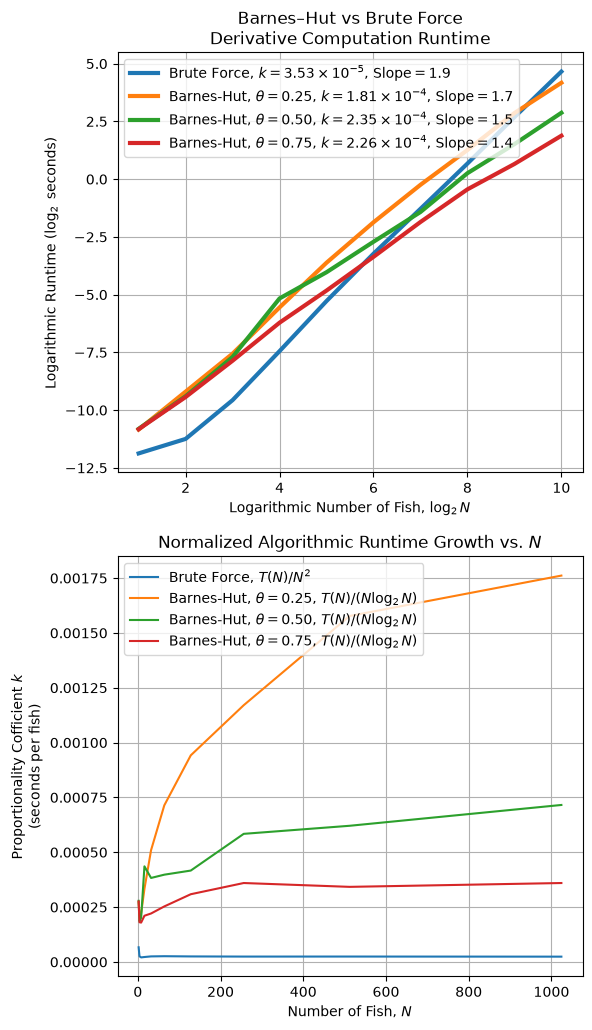

In [59]:
generate_comparison_fig(1, 10)